# Final Project - BeautifulSoup Documentation Analytics
**Collect - Parse - Extract - Analyze - Visualize**

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

In [28]:
url = "https://www.crummy.com/software/BeautifulSoup/bs4/doc/"
response = requests.get(url, timeout=20)
print(response.status_code)
html = response.text

# Luu HTML ra file
os.makedirs('../data/raw', exist_ok=True)
with open('../data/raw/beautifulsoup_doc.html', 'w', encoding='utf-8') as f:
    f.write(html)

200


In [29]:
soup = BeautifulSoup(html, 'lxml')

# Kiem tra tieu de trang
title = soup.title.string.strip()
print(title)

Beautiful Soup Documentation — Beautiful Soup 4.14.3 documentation


In [30]:
# Trich xuat tat ca headings
headings = soup.find_all(['h1', 'h2', 'h3'])
print("Total headings found:", len(headings))

Total headings found: 113


### 1. Dataset Overview

This analysis is based on the official BeautifulSoup 4 documentation. The downloaded HTML page has been processed into three structured CSV datasets located in `data/processed/`:
- `sections.csv`: Contains metadata about document sections (titles, word counts, links, code examples).
- `links.csv`: Contains all hyperlinks in the document, classified by type.
- `code_examples.csv`: Contains all Python code examples extracted from the document.

In [31]:
# Tao DataFrame sections (vi du rut gon)
import pandas as pd
# ... code xu ly de tao dataframe sections ...
df_sections = pd.read_csv('../data/processed/sections.csv')
print("--- Sections Preview (first 5 rows) ---")
display(df_sections.head())

# Tai va hien thi them cac dataset con lai
df_links = pd.read_csv('../data/processed/links.csv')
df_code = pd.read_csv('../data/processed/code_examples.csv')

print(f"\nLinks dataset shape: {df_links.shape}")
print(f"Code examples dataset shape: {df_code.shape}")

print("\n--- Links Preview (first 5 rows) ---")
display(df_links.head())

print("\n--- Code Examples Preview (first 5 rows) ---")
display(df_code.head())

--- Sections Preview (first 5 rows) ---


,section_id,section_level,section_title,section_text,word_count,code_block_count,link_count
0,1,h1,Beautiful Soup Documentation,Beautiful Soup Documentation ¶ Beautiful Soup ...,214,0,10
1,2,h2,Getting help,Getting help ¶ If you have questions about Bea...,54,0,3
2,3,h3,API documentation,API documentation ¶ This document is written l...,46,0,2
3,4,h1,Quick Start,Quick Start ¶ Here's an HTML document I'll be ...,425,5,1
4,5,h1,Installing Beautiful Soup,Installing Beautiful Soup ¶ If you're using a ...,216,0,3



Links dataset shape: (504, 4)
Code examples dataset shape: (220, 9)

--- Links Preview (first 5 rows) ---


,link_text,href,link_type,section_title
0,¶,#beautiful-soup-documentation,internal_anchor,Beautiful Soup Documentation
1,Beautiful Soup,http://www.crummy.com/software/BeautifulSoup/,documentation_link,Beautiful Soup Documentation
2,Beautiful Soup 3,http://www.crummy.com/software/BeautifulSoup/b...,documentation_link,Beautiful Soup Documentation
3,Porting code to BS4,#porting-code-to-bs4,internal_anchor,Beautiful Soup Documentation
4,这篇文档当然还有中文版.,https://www.crummy.com/software/BeautifulSoup/...,documentation_link,Beautiful Soup Documentation



--- Code Examples Preview (first 5 rows) ---


,example_id,section_title,code_text,line_count,contains_find_all,contains_find,contains_select,contains_get_text,contains_requests
0,1,Quick Start,"html_doc = """"""<html><head><title>The Dormouse'...",12,False,False,False,False,False
1,2,Quick Start,from bs4 import BeautifulSoup\nsoup = Beautifu...,36,False,False,False,False,False
2,3,Quick Start,soup.title\n# <title>The Dormouse's story</tit...,28,True,True,False,False,False
3,4,Quick Start,for link in soup.find_all('a'):\n print(lin...,5,True,False,False,False,False
4,5,Quick Start,print(soup.get_text())\n# The Dormouse's story...,12,False,False,False,True,False


### 2. Scraping Method

- **Web Page Collector**: Using the `requests` library to fetch the HTML contents of the official documentation page, saving the raw data into `data/raw/beautifulsoup_doc.html` for reproducibility.
- **HTML Parser & Section Extractor**: Using `BeautifulSoup4` with the `lxml` parser to extract documentation sections (separated by `h1`/`h2`/`h3` headings) and calculating metadata like text word count, link count, and code example count.
- **Link Extractor**: Iterating through all `<a>` tags and classifying links into 5 types (`internal_anchor`, `external_link`, `documentation_link`, `image_link`, `empty_or_invalid`).
- **Code Example Extractor**: Extracting python code blocks from `<pre>` tags and flagging the presence of core BeautifulSoup methods and libraries.

### 3. Extracted Data Summary

Here we compute and print a general summary of the extracted structures.

In [32]:
total_sections = len(df_sections)
longest_section = df_sections.loc[df_sections['word_count'].idxmax()]
total_links = len(df_links)
total_code_examples = len(df_code)

print(f"Extracted Data Summary:")
print(f"- Total Sections extracted: {total_sections}")
print(f"- Longest Section by word count: '{longest_section['section_title']}' ({longest_section['word_count']} words)")
print(f"- Total Hyperlinks extracted and classified: {total_links}")
print(f"- Total Python Code Examples extracted: {total_code_examples}")

Extracted Data Summary:
- Total Sections extracted: 113
- Longest Section by word count: 'Multi-valued attributes' (852 words)
- Total Hyperlinks extracted and classified: 504
- Total Python Code Examples extracted: 220


### 4. Analysis Results

Below we execute the code to answer the 8 mandatory analytical questions and 2 proposed advanced questions using Pandas and NumPy.

In [33]:
print("=== MANDATORY QUESTIONS ===")

# Q1: How many sections
print(f"Q1: How many sections are in the documentation? -> {len(df_sections)}")

# Q2: Highest word count
idx_max_words = df_sections['word_count'].idxmax()
q2_sec = df_sections.loc[idx_max_words]
print(f"Q2: Which section has the highest word count? -> '{q2_sec['section_title']}' ({q2_sec['word_count']} words)")

# Q3: Most code examples
idx_max_code = df_sections['code_block_count'].idxmax()
q3_sec = df_sections.loc[idx_max_code]
print(f"Q3: Which section contains the most code examples? -> '{q3_sec['section_title']}' ({q3_sec['code_block_count']} examples)")

# Q4: Most links
idx_max_links = df_sections['link_count'].idxmax()
q4_sec = df_sections.loc[idx_max_links]
print(f"Q4: Which section contains the most links? -> '{q4_sec['section_title']}' ({q4_sec['link_count']} links)")

# Q5: Top 10 frequent technical keywords
import json
with open('../output/analysis_results.json', 'r', encoding='utf-8') as f:
    analysis_data = json.load(f)
print("Q5: Top 10 most frequent technical keywords:")
for i, kw in enumerate(analysis_data['q5_top10_keywords'][:10], 1):
    print(f"   {i}. {kw['keyword']}: {kw['frequency']} times")

# Q6: Internal vs External links
link_counts = df_links['link_type'].value_counts()
internal_count = link_counts.get('internal_anchor', 0)
external_count = link_counts.get('external_link', 0)
print(f"Q6: How many internal and external links exist? -> Internal: {internal_count}, External: {external_count}")

# Q7: find_all() usage in code examples
fa_count = df_code['contains_find_all'].sum()
print(f"Q7: How many code examples use find_all()? -> {fa_count}")

# Q8: get_text() usage in code examples
gt_count = df_code['contains_get_text'].sum()
print(f"Q8: How many code examples use get_text()? -> {gt_count}")

print("\n=== ADDITIONAL QUESTIONS ===")
# Q9: Word count stats
mean_w = df_sections['word_count'].mean()
median_w = df_sections['word_count'].median()
std_w = df_sections['word_count'].std()
print(f"Q9 (Extra): Word count statistics across sections -> Mean: {mean_w:.1f}, Median: {median_w:.1f}, Std: {std_w:.1f}")

# Q10: Code examples using any search method ratio
percentage = analysis_data['q10_bs4_method_usage_ratio']['percentage']
print(f"Q10 (Extra): % of code examples using at least one search method -> {percentage}%")

=== MANDATORY QUESTIONS ===
Q1: How many sections are in the documentation? -> 113
Q2: Which section has the highest word count? -> 'Multi-valued attributes' (852 words)
Q3: Which section contains the most code examples? -> 'Multi-valued attributes' (13 examples)
Q4: Which section contains the most links? -> 'Table of Contents' (128 links)
Q5: Top 10 most frequent technical keywords:
   1. soup: 516 times
   2. tag: 432 times
   3. html: 266 times
   4. class: 258 times
   5. find: 199 times
   6. string: 196 times
   7. link: 184 times
   8. href: 170 times
   9. parser: 151 times
   10. beautifulsoup: 149 times
Q6: How many internal and external links exist? -> Internal: 470, External: 19
Q7: How many code examples use find_all()? -> 39
Q8: How many code examples use get_text()? -> 4

=== ADDITIONAL QUESTIONS ===
Q9 (Extra): Word count statistics across sections -> Mean: 173.4, Median: 139.0, Std: 135.4
Q10 (Extra): % of code examples using at least one search method -> 30.0%


### 5. Charts

Below we generate and display the required 4 charts inline.

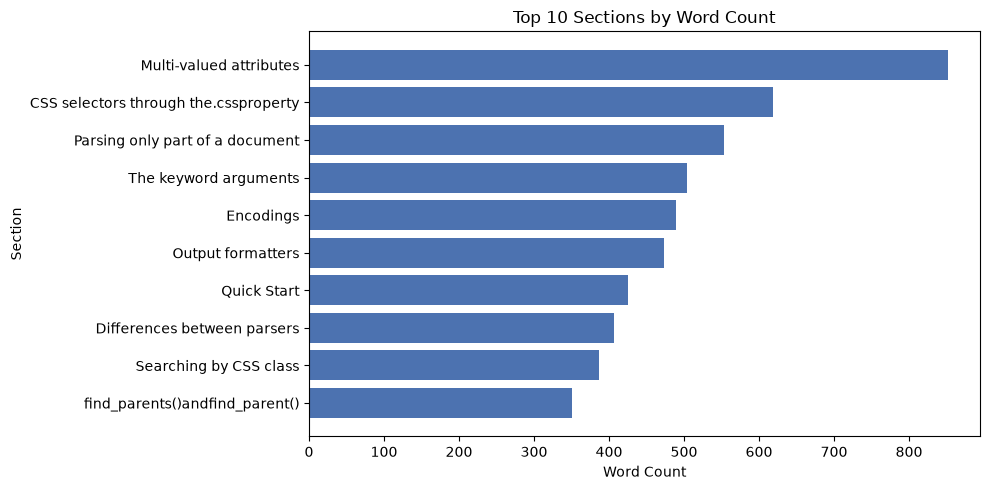

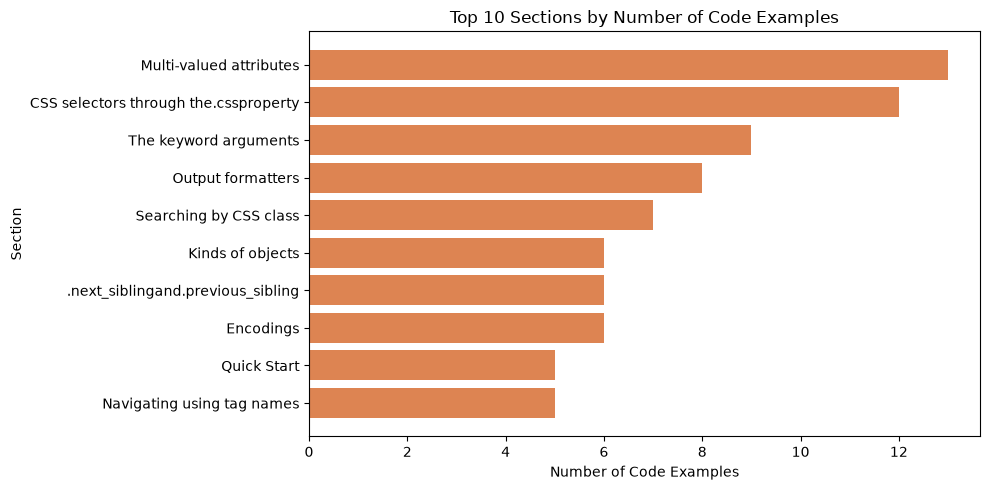

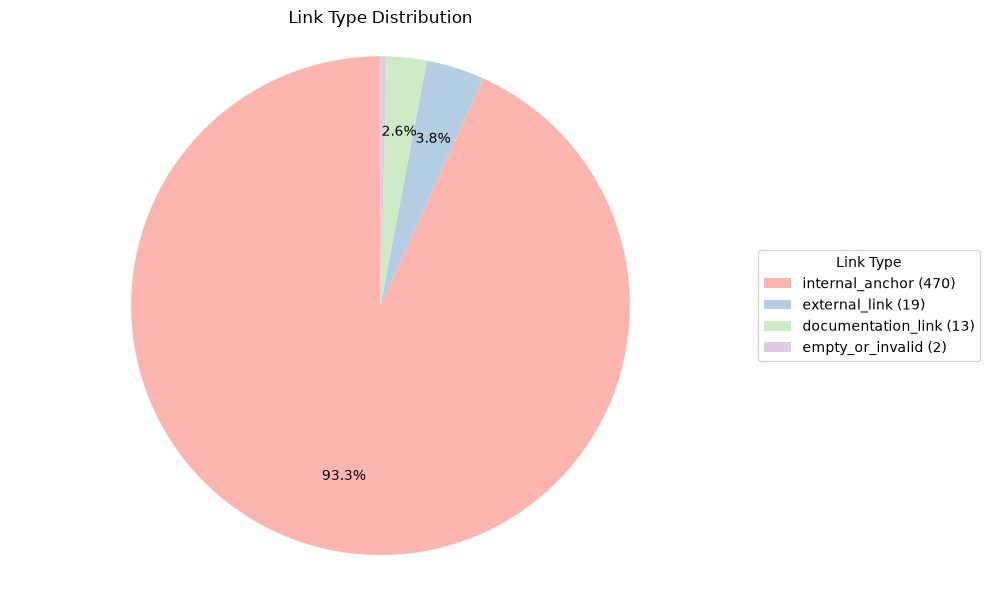

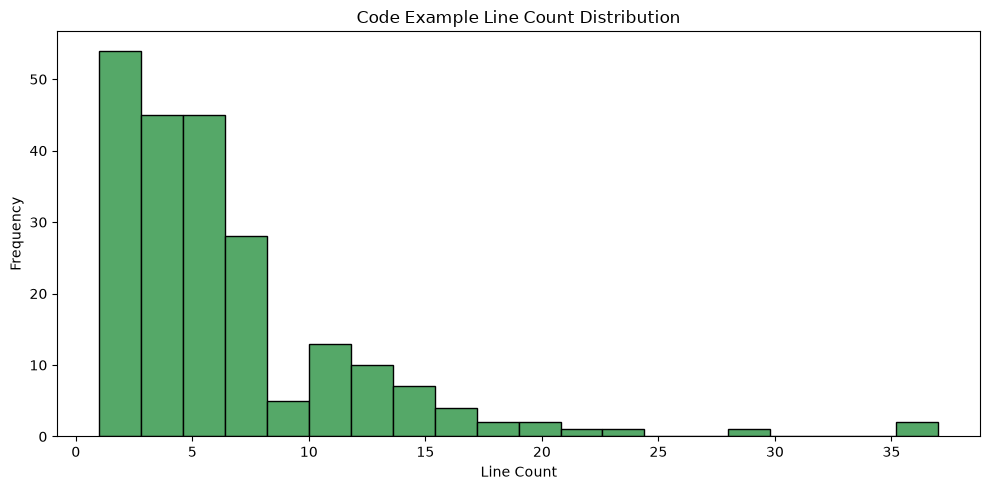

In [34]:
# Chart 1: Top 10 sections by word count
plt.figure(figsize=(10, 5))
top10_w = df_sections.sort_values('word_count', ascending=False).head(10)
plt.barh(top10_w['section_title'], top10_w['word_count'], color='#4C72B0')
plt.xlabel('Word Count')
plt.ylabel('Section')
plt.title('Top 10 Sections by Word Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Chart 2: Number of code examples by section
plt.figure(figsize=(10, 5))
code_counts = df_code['section_title'].value_counts().head(10)
plt.barh(code_counts.index, code_counts.values, color='#DD8452')
plt.xlabel('Number of Code Examples')
plt.ylabel('Section')
plt.title('Top 10 Sections by Number of Code Examples')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Chart 3: Link type distribution
fig, ax = plt.subplots(figsize=(10, 6))
link_types = df_links['link_type'].value_counts()
wedges, _, _ = ax.pie(
    link_types.values,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=90,
    colors=plt.cm.Pastel1.colors[:len(link_types)],
    pctdistance=0.7
)
ax.legend(
    wedges,
    [f"{t} ({c})" for t, c in link_types.items()],
    title="Link Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax.set_title('Link Type Distribution')
ax.axis('equal')
plt.tight_layout()
plt.show()

# Chart 4: Code example line count distribution
plt.figure(figsize=(10, 5))
plt.hist(df_code['line_count'], bins=20, color='#55A868', edgecolor='black')
plt.xlabel('Line Count')
plt.ylabel('Frequency')
plt.title('Code Example Line Count Distribution')
plt.tight_layout()
plt.show()

### 6. Key Findings

- **High-Density Content**: Core reference sections like "Multi-valued attributes" contain the bulk of the words and examples.
- **Highly Self-Referential**: Over 90% of links in the documentation are internal anchors, indicating it is optimized for browsing within a single page.
- **Search Method Centrality**: A high proportion of code examples demonstrate search methods (`find_all`, `find`, or `select`), showing their central role in BeautifulSoup usage.

### 7. Limitations

- **Single Page Scope**: The analysis only considers the main documentation page and may not reflect documentation splits or external tutorials.
- **Inconsistent Structure**: Section splitting relies heavily on headers (`h1`-`h3`); any nesting structural inconsistencies in the raw HTML can affect section boundaries.

### 8. Conclusion

The BeautifulSoup Documentation Analytics System successfully showcases how an automated data engineering pipeline can collect web pages, extract meaningful structures (sections, links, code examples), and perform key analytical inquiries.

In [39]:
# Programmatic call to create the PDF report
import sys
sys.path.append('../src')
from report_generator import run_report_generator

print("Generating output/final_report.pdf ...")
pdf_path = run_report_generator(analysis_data)
print(f"Report generated successfully at: {pdf_path}")

Generating output/final_report.pdf ...
Starting final report generation...
Successfully exported final_report.pdf
Report generated successfully at: C:\Users\nghia\OneDrive\Desktop\hk5\PDS301m\PDS301m_Project_Group2\output\final_report.pdf
